# Notebook 2: Handling Class Imbalance

## 1. Setup and Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              accuracy_score, roc_auc_score,
                              average_precision_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
import warnings, os

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
# os.makedirs('plots', exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [12]:
df = pd.read_csv('data/processed_telco_scaled.csv')
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified 70/30 split — test set is held out and NEVER seen during resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")

Train: (4922, 23)  |  Test: (2110, 23)
Train churn rate: 26.6%  |  Test churn rate: 26.6%


## 2. Class Imbalance Visualisation

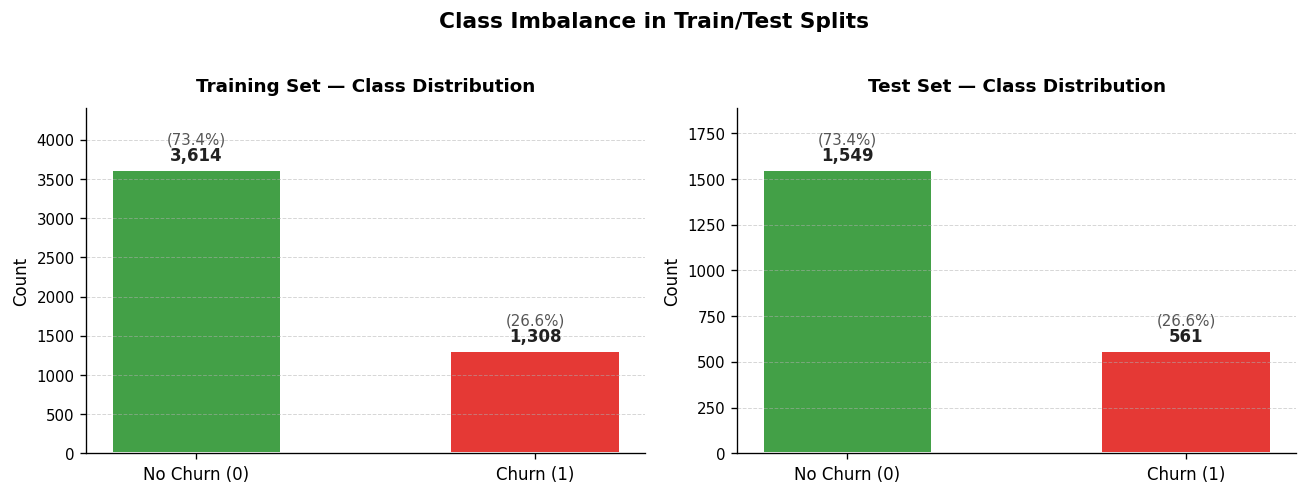

Class Ratio (Majority:Minority) = 2.76:1


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, y_split) in zip(axes, [('Training Set', y_train), ('Test Set', y_test)]):
    counts = y_split.value_counts().sort_index()  # ensure 0 before 1
    labels = ['No Churn (0)', 'Churn (1)']
    colors = ['#43A047', '#E53935']
    x = range(len(labels))

    bars = ax.bar(x, counts.values, color=colors, edgecolor='white',
                  linewidth=1.2, width=0.5)

    # Annotate bars — count on top, percentage below it
    for bar, v, total in zip(bars, counts.values, [len(y_split)] * 2):
        pct = v / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts.values) * 0.02,   # dynamic offset
            f"{v:,}",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#212121'
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts.values) * 0.08,   # sits above count
            f"({pct:.1f}%)",
            ha='center', va='bottom',
            fontsize=9, fontweight='normal', color='#555555'
        )

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{name} — Class Distribution',
                 fontsize=11, fontweight='bold', pad=10)

    # Leave headroom so top annotations aren't clipped
    ax.set_ylim(0, max(counts.values) * 1.22)

    # Clean up spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.yaxis.set_tick_params(labelsize=9)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)

plt.suptitle('Class Imbalance in Train/Test Splits',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('plots/06_class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Class Ratio (Majority:Minority) = {ratio:.2f}:1")

## 3. Handling Imbalance 

In [14]:
# Save the resampled training set
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE training set: {pd.Series(y_train_smote).value_counts().to_dict()}")

# Save full train/test splits for Notebook 3
import pickle, os
os.makedirs('data', exist_ok=True)
with open('data/train_test_split.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test,
                  X_train_smote, y_train_smote), f)
print("\n✅ Data splits saved to data/train_test_split.pkl")

SMOTE training set: {1: 3614, 0: 3614}

✅ Data splits saved to data/train_test_split.pkl
